In [5]:
from pathlib import Path
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    PROJECT_ROOT = Path("/content/drive/MyDrive/CBB_IGWP")

else:
    PROJECT_ROOT = Path.cwd().parent

sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Mounted at /content/drive
Project root: /content/drive/MyDrive/CBB_IGWP


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from download_data import *
from game_eval import game_eval
from ingame_winprob import *
from model_eval import *
from train_model import *
from win_probability_chart import *
from game_analysis import *

In [7]:
download_processed_data()

✓ train.csv already exists.
✓ test.csv already exists.
✓ igwp_test.csv already exists.
✓ game_comebacks_df.csv already exists.
✓ game_swings_df.csv already exists.

Download complete.


In [8]:
download_raw_data()

✓ teams.csv already exists.
✓ possessions.csv already exists.


Downloading...
From: https://drive.google.com/uc?id=1UrADG9cHl4ALU1rYjPRp22ty_VYcavSD
To: /content/drive/MyDrive/CBB_IGWP/data/raw/teams_date_stats.csv
100%|██████████| 2.22M/2.22M [00:00<00:00, 81.9MB/s]


Download complete.


Load Source data

In [12]:
possessions = pd.read_csv(RAW_DIR/"possessions.csv")
train = pd.read_csv(PROCESSED_DIR/"train.csv")
test = pd.read_csv(PROCESSED_DIR/"test.csv")
print(train.shape)
print(test.shape)
print(possessions.shape)

(435928, 31)
(108722, 31)
(552833, 47)


Train Following Model:

$$z = X_1 \cdot \frac{\text{Lead} \pm \text{poss}}{t^{y_1}} + X_2 \cdot \frac{t}{40} \cdot \frac{\text{adj\_spread}}{t^{y_2}}$$

Each possession calculates the favorite's win probability at time remaining t, given three inputs: current lead, possession, and pregame net rating spread. The possession term represents projected points on the current possession, estimated from each team's offensive and defensive ratings. X1 and X2 are linear coefficients controlling the influence of the lead and spread terms respectively, while Y1 and Y2 are time-decay exponents controlling how quickly each term's impact changes as time remaing decreases.

In [13]:
result = train_model(train)
x1, x2, y1, y2 = result.x
print("Trained coefficients:")
print(f"x1 = {x1:.6f}")
print(f"x2 = {x2:.6f}")
print(f"y1 = {y1:.6f}")
print(f"y2 = {y2:.6f}")
print(f"Log loss: {result.fun:.6f}")

/content/drive/MyDrive/CBB_IGWP/train_model.py:16: RuntimeWarning: overflow encountered in exp
  p = np.clip(1 / (1 + np.exp(-z)), 1e-15, 1 - 1e-15)


Trained coefficients:
x1 = 0.412912
x2 = 2.082151
y1 = 0.344548
y2 = 0.716343
Log loss: 0.370532


In [ ]:
# iterate through test games, evaluate win probabilities for each possession using trained data
test_ids = test['game_id'].unique()
results_test = []
for i, game_id in enumerate(test_ids, 1):
  result = game_eval(test, game_id)
  results_test.append(result)


igwp_test = pd.concat(results_test, ignore_index=True)
igwp_test.to_csv("igwp_test.csv", index=False)
print(f"\nWritten {len(igwp_test):,} rows across {len(test_ids)} games to {"igwp_test.csv"}")


Written 108,722 rows across 788 games to igwp_test.csv


In [14]:
# When rerunning, rather than retraining model just reads saved test file
igwp_test = pd.read_csv(PROCESSED_DIR/"igwp_test.csv")
print(igwp_test.shape)

(108722, 28)


In [15]:
# Print the model scores for CBB Analytics current March Madness in game win probability
print("CBB Analytics Bracket scores:")
print(f"Brier Score: {calc_brier(igwp_test, 0):.6f}")
print(f"Log Loss:    {calc_logloss(igwp_test, 0):.6f}")
print(f"Cal MAE:     {calc_cal_mae(igwp_test, 20, 0):.6f}")
print(f"Cal RMSE:    {calc_cal_rmse(igwp_test, 20, 0):.6f}")

CBB Analytics Bracket scores:
Brier Score: 0.118986
Log Loss:    0.368521
Cal MAE:     0.043736
Cal RMSE:    0.053399


In [ ]:
# Print scores for trained Logistic Regression Model
print("Logistic Regression scores:")
print(f"Brier Score: {calc_brier(igwp_test, 2):.6f}")
print(f"Log Loss:    {calc_logloss(igwp_test, 2):.6f}")
print(f"Cal MAE:     {calc_cal_mae(igwp_test, 20, 2):.6f}")
print(f"Cal RMSE:    {calc_cal_rmse(igwp_test, 20, 2):.6f}")

Logistic Regression scores:
Brier Score: 0.116777
Log Loss:    0.359568
Cal MAE:     0.010732
Cal RMSE:    0.013323


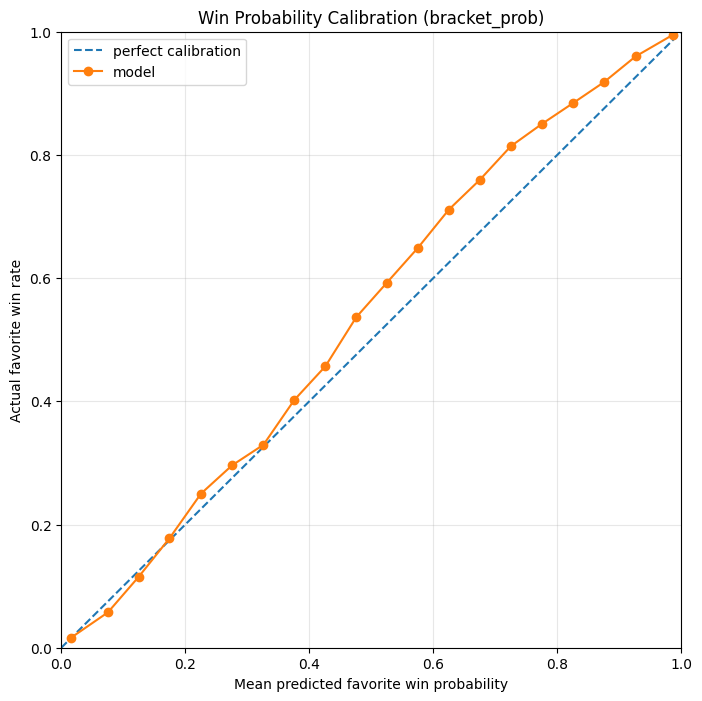

In [ ]:
# Bracket Calibration plot
plot_calibration(igwp_test, 20,0)
plt.show()

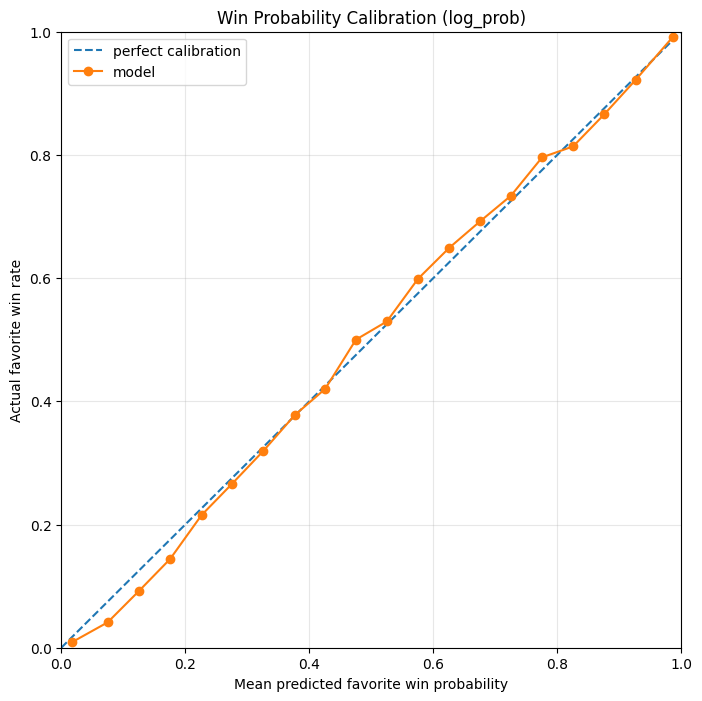

In [ ]:
# Logistic Calibration plot
plot_calibration(igwp_test, 20,2)
plt.show()

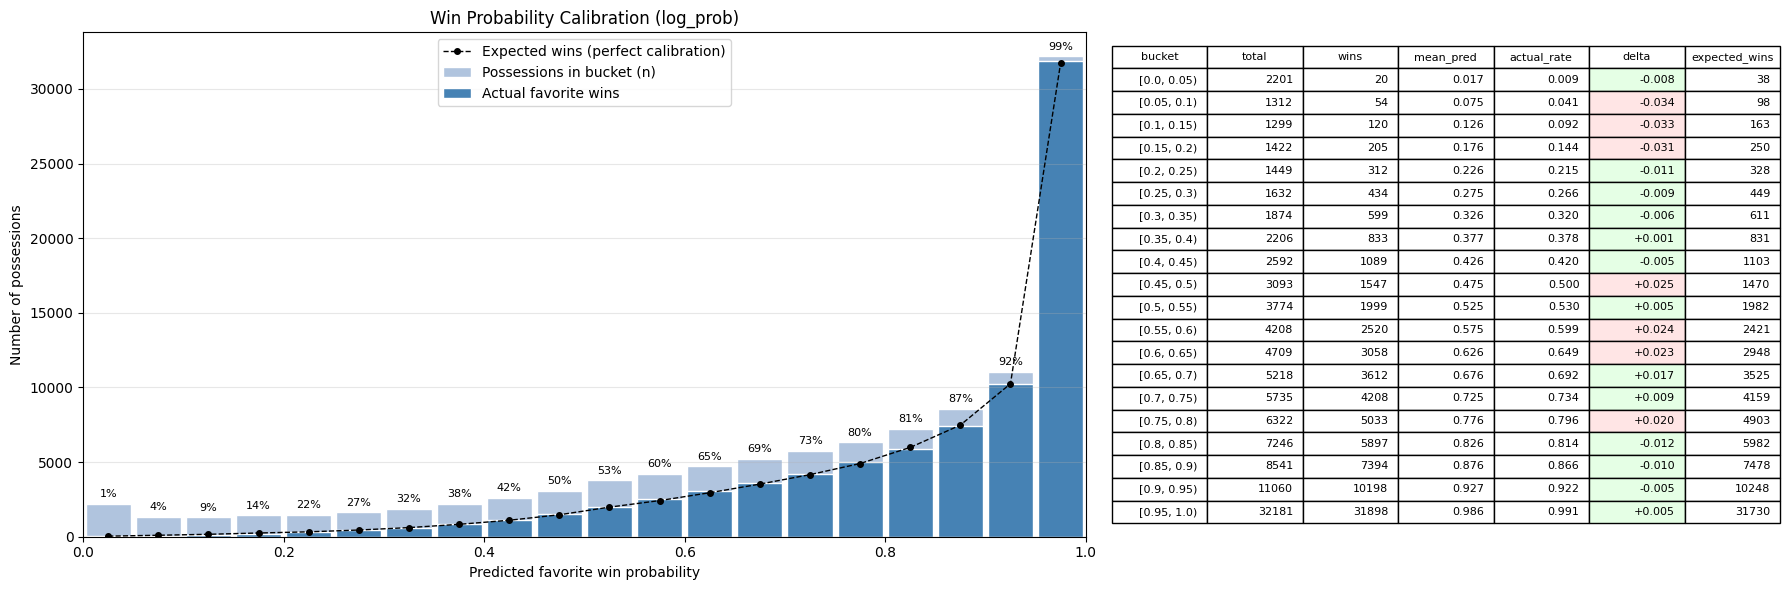

In [ ]:
# Calibration historgram bucketed by predicted win probability
plot_winprob_histogram(igwp_test, model=2)
plt.show()

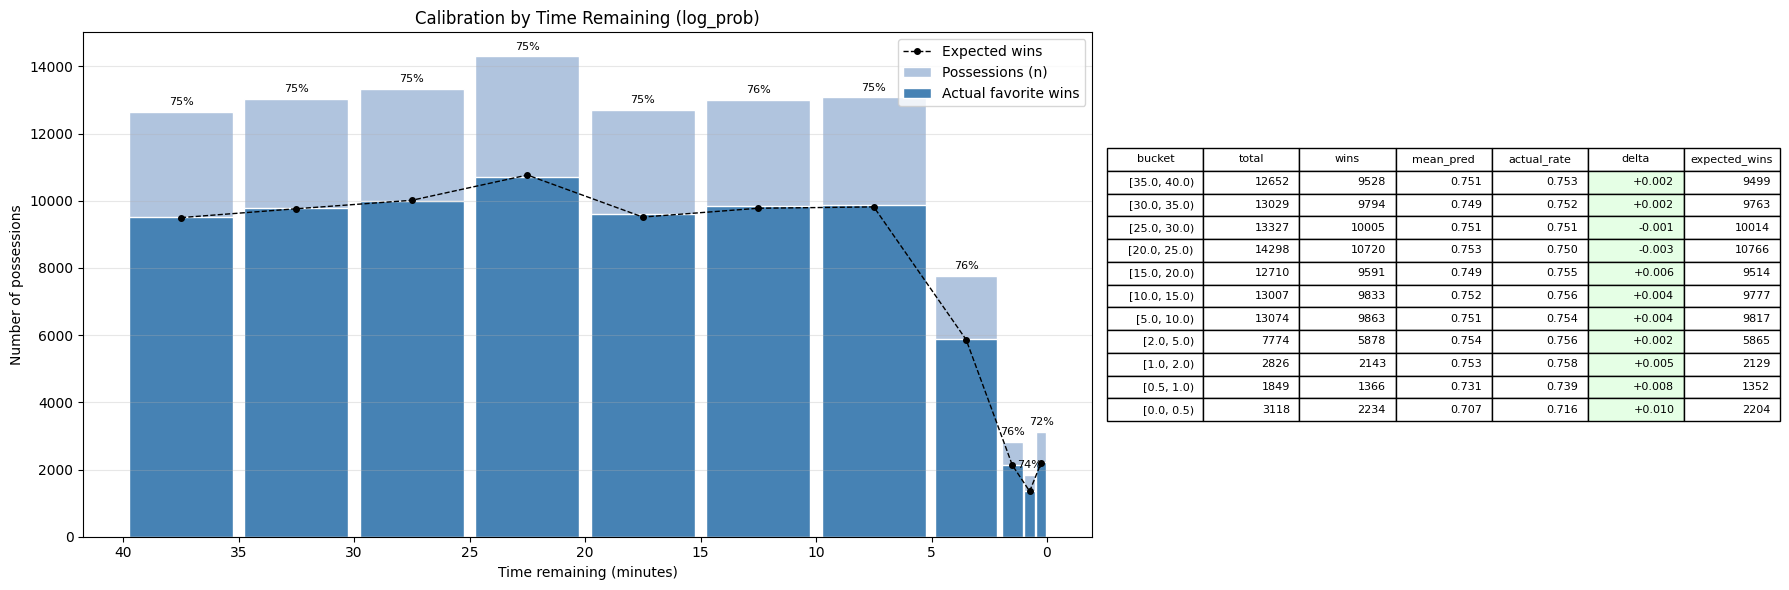

In [ ]:
# Calibration historgram bucketed by time remaining
plot_time_histogram(igwp_test, model=2)
plt.show()

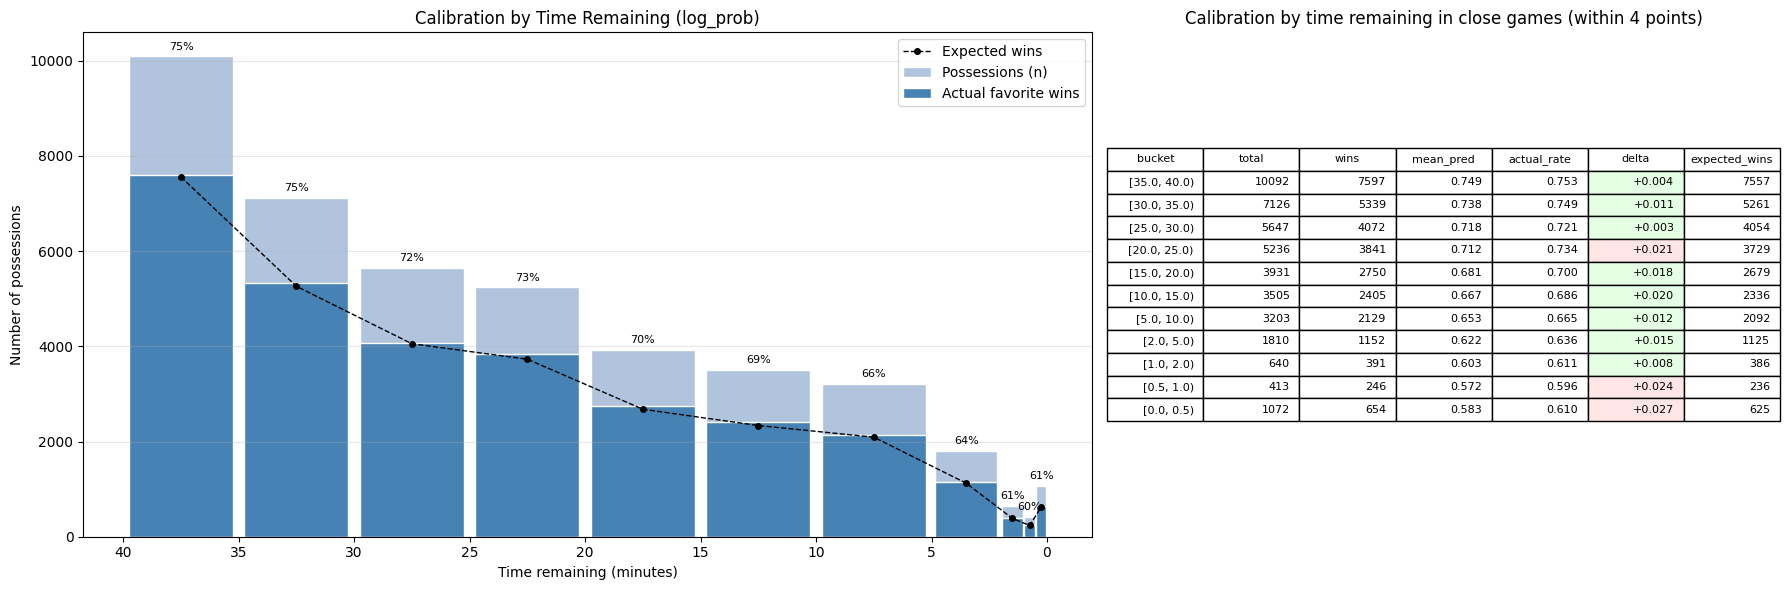

In [ ]:
# Evaluates model performance in close game scenarios
filtered_igwp_test = igwp_test[igwp_test['lead'].between(-4, 4)]
plot_time_histogram(filtered_igwp_test, model=2)
plt.title("Calibration by time remaining in close games (within 4 points)")
plt.show()

## **Model Insights**
1. **comebacks**: For each game, finds the possession where the eventual winning team's win probability was at its lowest — i.e., how close they came to losing. Returns one row per game.

2. **swings**: For each game, finds the single possession with the largest change in win probability from the possession before it — the biggest "swing" moment. Returns one row per game.

In [ ]:
game_comebacks_df = comebacks(igwp_test)
game_comebacks_df = game_comebacks_df.sort_values(by='lowest_prob', ascending=False)
# Prints the ten biggest comebacks, the probability, and the game context
print(game_comebacks_df[['game_id', 'team_market', 'team_name', 'team_market_agst',
       'team_name_agst', 'poss_num', 'time_rem', 'favorite_score',
       'underdog_score', 'result','lowest_prob']].tail(10))

       game_id      team_market  team_name   team_market_agst  team_name_agst  \
93313  2755786          Belmont     Bruins      Southern Ill.         Salukis   
59436  2715930             SIUE    Cougars        Little Rock         Trojans   
2200   2525408  St. John's (NY)  Red Storm             Baylor           Bears   
71198  2736294   Boston College     Eagles  Central Conn. St.     Blue Devils   
90370  2753455    Saint Peter's   Peacocks              Rider          Broncs   
25717  2546830   UNC Greensboro   Spartans             Mercer           Bears   
79404  2742673      Wichita St.   Shockers          Charlotte           49ers   
26301  2546868         Bucknell      Bison             Lehigh  Mountain Hawks   
5675   2526787         Columbia      Lions          Princeton          Tigers   
86060  2749599    South Alabama    Jaguars       Arkansas St.      Red Wolves   

       poss_num  time_rem  favorite_score  underdog_score  result  lowest_prob  
93313       128      2.73  

In [ ]:
# Example usage:
game_swings_df = swings(igwp_test)
game_swings_df = game_swings_df.sort_values(by='biggest_swing', ascending=False)
# Prints the biggest single play swings and game context
print(game_swings_df[['game_id', 'team_market', 'team_name', 'team_market_agst',
       'team_name_agst', 'poss_num', 'time_rem', 'favorite_score',
       'underdog_score', 'result','biggest_swing']].head(10))

        game_id      team_market      team_name team_market_agst  \
2203    2525408  St. John's (NY)      Red Storm           Baylor   
93326   2755786          Belmont         Bruins    Southern Ill.   
14540   2537763           Tulane     Green Wave      New Orleans   
105301  2810639  St. Thomas (MN)        Tommies     North Dakota   
53985   2696331             UMBC     Retrievers       Morgan St.   
23009   2546430         Syracuse         Orange   Boston College   
59740   2715940        UT Martin       Skyhawks      Little Rock   
43998   2555178         Utah St.         Aggies        Boise St.   
108309  2829161          Florida         Gators             Iowa   
75864   2739214      Wake Forest  Demon Deacons   Boston College   

        team_name_agst  poss_num  time_rem  favorite_score  underdog_score  \
2203             Bears       181      0.00              98              99   
93326          Salukis       141      0.00              67              68   
14540       Priva

In [18]:
game_comebacks_df = pd.read_csv(PROCESSED_DIR/"game_comebacks_df.csv")
game_swings_df = pd.read_csv(PROCESSED_DIR/"game_swings_df.csv")

## **In Game Win probability chart**
Takes possession/win probability data and a game id and visualizes the winning teams probability progression throughout the game


In [16]:
import importlib
import win_probability_chart
importlib.reload(win_probability_chart)

<module 'win_probability_chart' from '/content/drive/MyDrive/CBB_IGWP/win_probability_chart.py'>

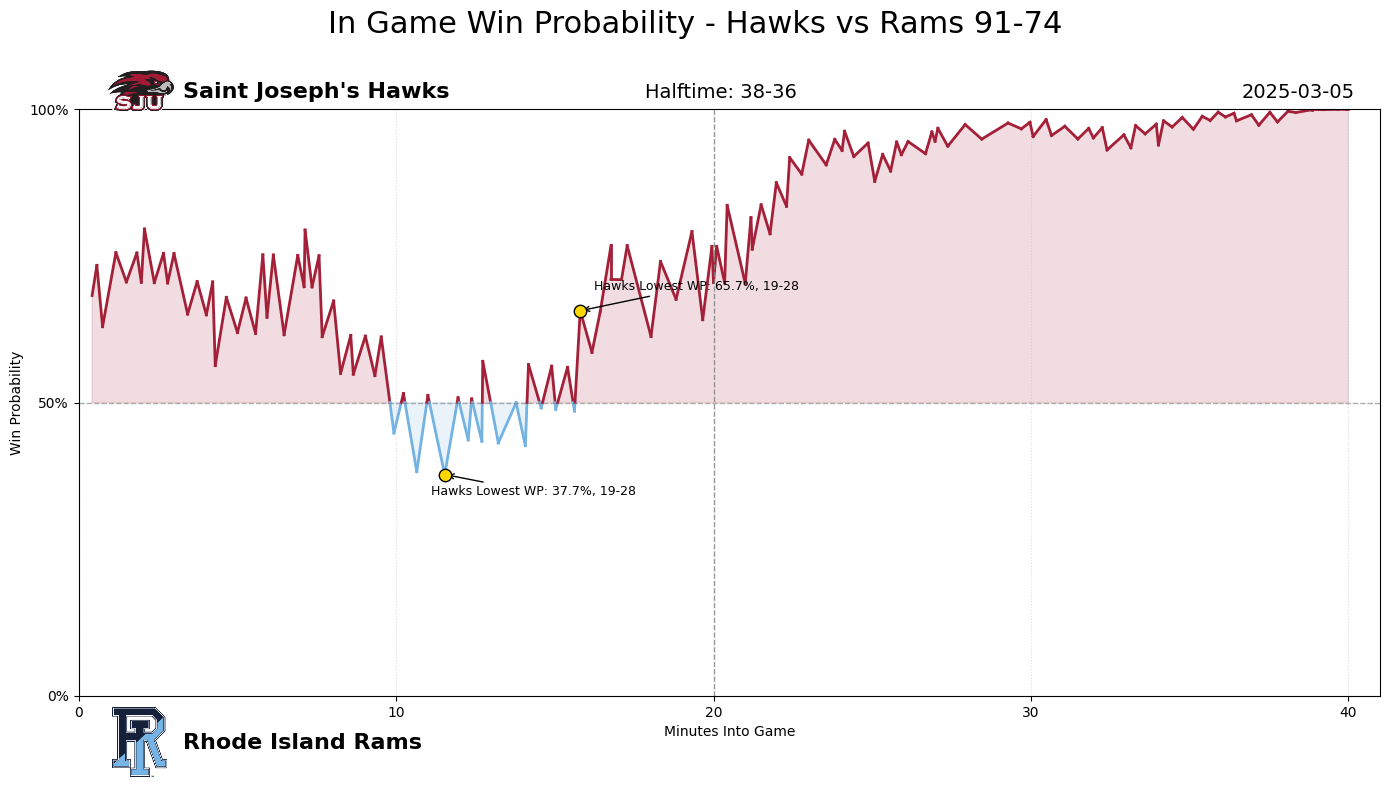

In [19]:
win_prob_chart(igwp_test,game_comebacks_df,game_swings_df, 2555841)

NameError: name 'game_comebacks_df' is not defined

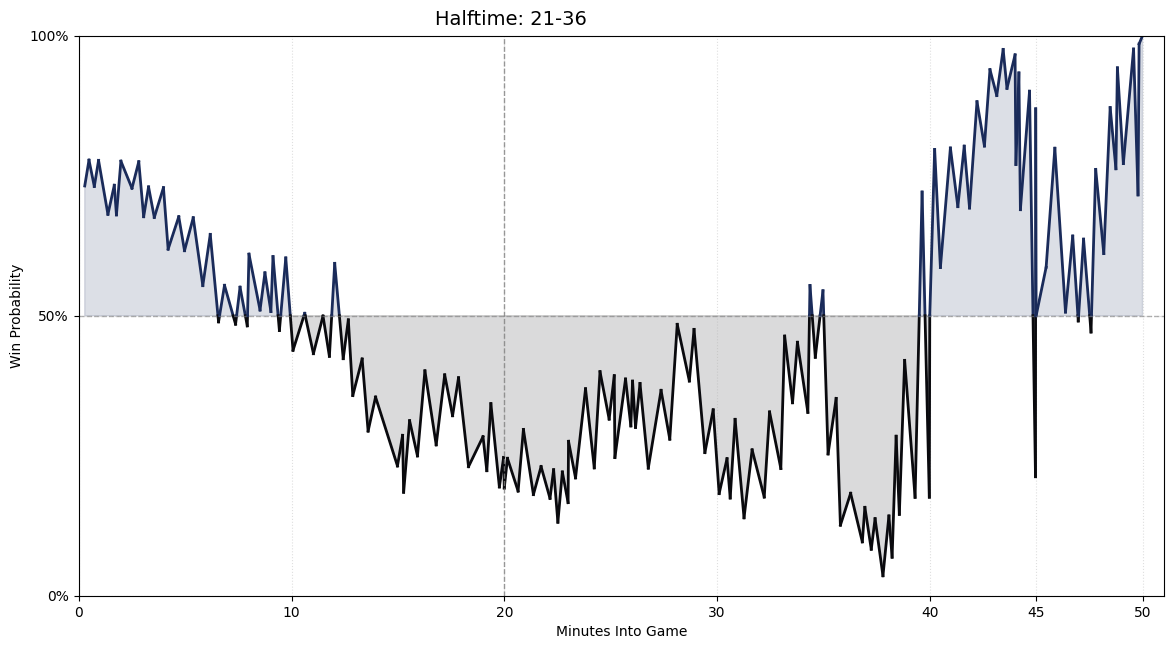

In [ ]:
win_prob_chart(igwp_test, 2633240)